## Рубежный контроль №1

- **Группа:** ИУ5-66Б
- **Студент:** Ордиянц Эрик
- **Вариант:** 14
- **Задача №2** – Обработка пропусков в данных
- **Дополнительное требование:** парные диаграммы (pairplot)

---


# Обработка пропусков и парные диаграммы (Admission Predict)

Набор: `Admission_Predict_Ver1.1.csv` — прогноз вероятности поступления.

**План:** загрузка и очистка имён столбцов → контролируемое введение пропусков в один категориальный и один количественный признак → заполнение пропусков → парные диаграммы → выбор признаков для моделей.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("Admission_Predict_Ver1.1.csv")
df.columns = df.columns.str.strip()
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## Пропуски в исходных данных

В файле **нет** зарегистрированных пропусков. Для выполнения задания по обработке пропусков **случайно маскируем** часть значений в:
- **категориальном** признаке `Research` (бинарный: 0/1, участие в исследованиях);
- **количественном** признаке `CGPA` (непрерывная шкала успеваемости).

Доля маскирования зафиксирована константой ниже (можно изменить).

In [ ]:
MISSING_FRAC = 0.08  # доля искусственно введённых пропусков

df_miss = df.copy()
n = len(df_miss)
k_cat = int(np.round(n * MISSING_FRAC))
k_num = int(np.round(n * MISSING_FRAC))

idx_cat = np.random.choice(df_miss.index, size=k_cat, replace=False)
idx_num = np.random.choice(df_miss.index, size=k_num, replace=False)

df_miss.loc[idx_cat, "Research"] = np.nan
df_miss.loc[idx_num, "CGPA"] = np.nan

print("Пропуски после маскирования:")
print(df_miss.isna().sum())

Пропуски после маскирования:
Serial No.            0
GRE Score             0
TOEFL Score           0
University Rating     0
SOP                   0
LOR                   0
CGPA                 40
Research             40
Chance of Admit       0
dtype: int64


## Категориальный признак `Research`

**Способ:** заполнение **наиболее частым значением (мода)** через `SimpleImputer(strategy="most_frequent")`.

**Зачем:** для номинальных/бинарных признаков среднее не имеет смысла; мода сохраняет доминирующий класс и не создаёт «дробных» категорий.

In [ ]:
imp_cat = SimpleImputer(strategy="most_frequent")
df_filled = df_miss.copy()
df_filled["Research"] = imp_cat.fit_transform(df_filled[["Research"]]).ravel()
assert df_filled["Research"].isna().sum() == 0
df_filled["Research"] = df_filled["Research"].astype(int)
df_filled["Research"].value_counts()

Research
1    294
0    206
Name: count, dtype: int64

## Количественный признак `CGPA`

**Способ:** заполнение **медианой** через `SimpleImputer(strategy="median")`.

**Зачем:** медиана устойчива к выбросам по сравнению со средним; для шкал вроде GPA это часто предпочтительнее среднего при произвольных пропусках.

In [ ]:
imp_num = SimpleImputer(strategy="median")
df_filled["CGPA"] = imp_num.fit_transform(df_filled[["CGPA"]]).ravel()
assert df_filled["CGPA"].isna().sum() == 0
df_filled[["CGPA"]].describe()

,CGPA
count,500.000000
mean,8.568600
std,0.584266
min,6.800000
25%,8.157500
50%,8.560000
75%,9.012500
max,9.920000


## Парные диаграммы (pair plot)

Строим по числовым признакам, влияющим на цель; цвет (`hue`) — `Research`, чтобы видеть разделение по категории.

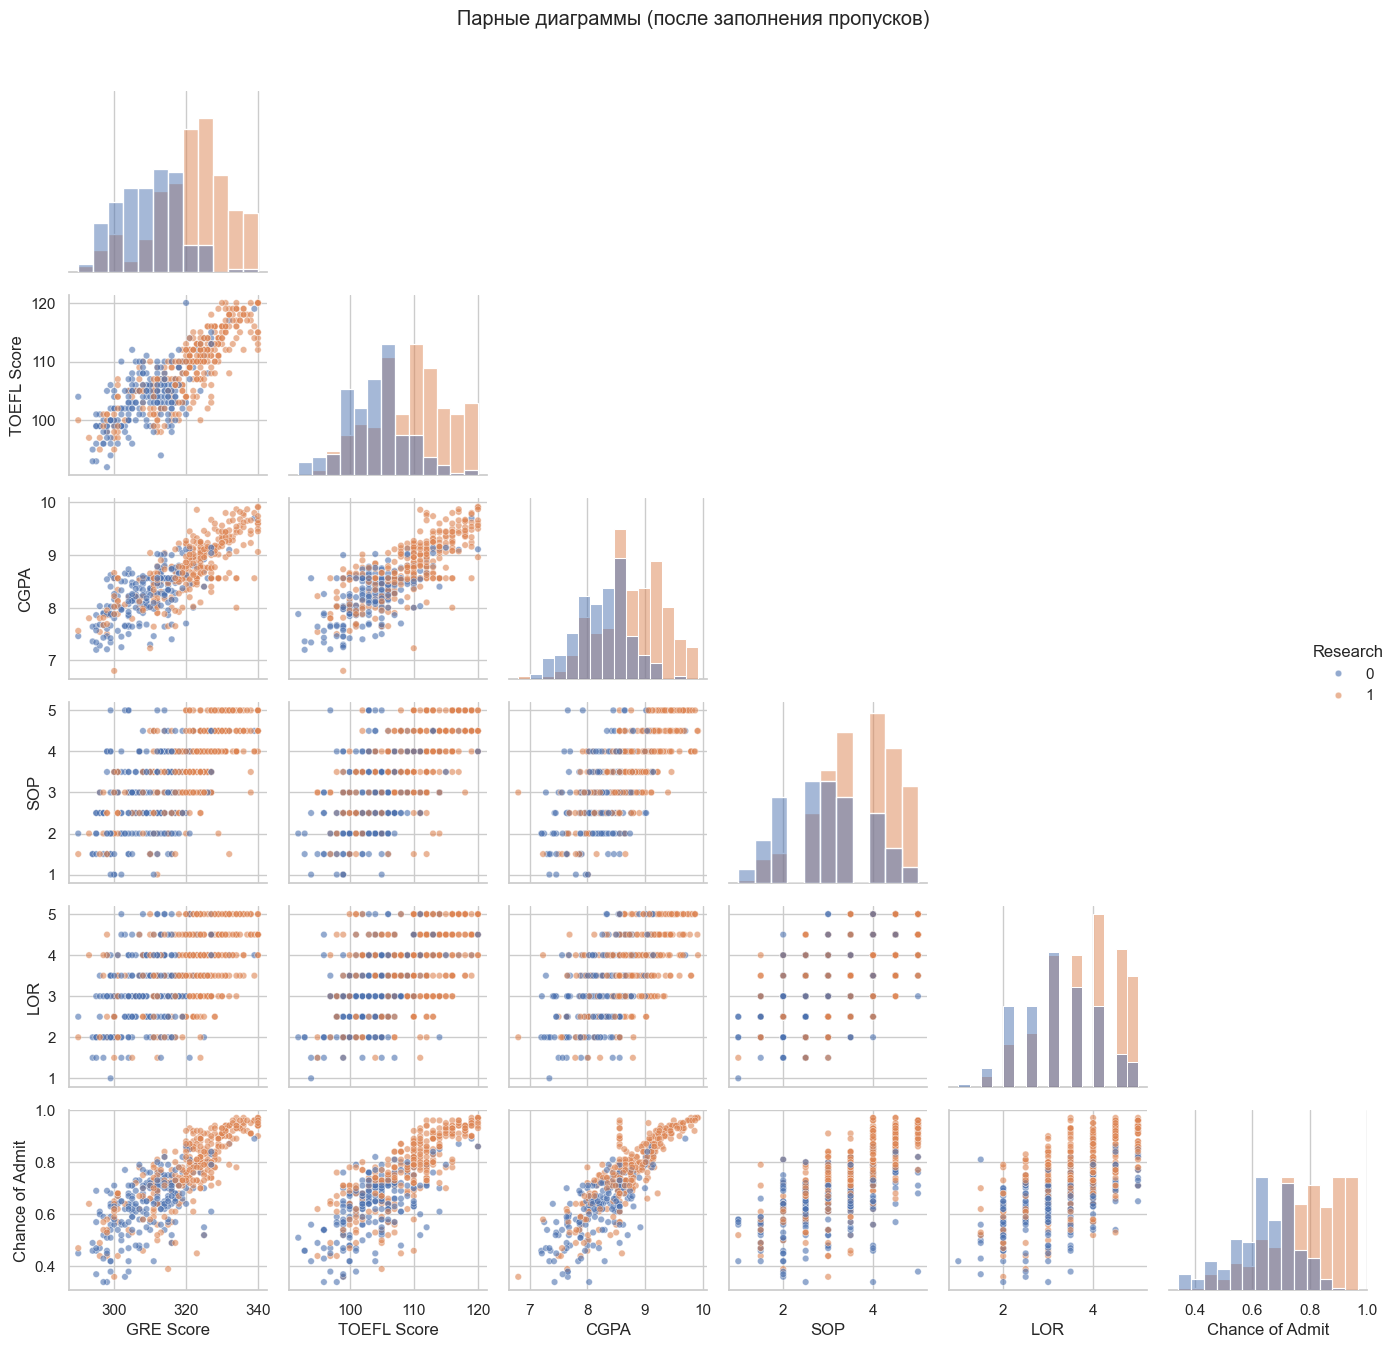

In [ ]:
target = "Chance of Admit"
pair_cols = [
    "GRE Score",
    "TOEFL Score",
    "CGPA",
    "SOP",
    "LOR",
    target,
]

g = sns.pairplot(
    df_filled[pair_cols + ["Research"]],
    hue="Research",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 22},
    diag_kind="hist",
    height=2.2,
)
g.fig.suptitle("Парные диаграммы (после заполнения пропусков)", y=1.02)
plt.tight_layout()
plt.show()

## Какие признаки использовать для моделей и почему

**Целевая переменная:** `Chance of Admit` — непрерывная вероятность/доля; задача регрессии.

**Признаки (рекомендуемый набор):**
- `GRE Score`, `TOEFL Score` — стандартизированные вступительные баллы, сильные предикторы.
- `University Rating`, `SOP`, `LOR` — ординальные оценки качества заявки; полезны как числовые шкалы 1–5.
- `CGPA` — академическая успеваемость; на парных графиках обычно теснее всего связана с целью.
- `Research` — бинарный индикатор; даёт сдвиг распределения цели между группами (видно по `hue` на pair plot).

**Исключить:** `Serial No.` — технический идентификатор, не несёт содержательной информации и приводит к переобучению/утечке, если трактовать как признак.

**Итог по обработке пропусков:**
- *Категориальные* (`Research`): **наиболее частая категория (мода)**.
- *Количественные* (`CGPA`): **медиана по столбцу**.

In [ ]:
feature_cols = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
]
X = df_filled[feature_cols]
y = df_filled[target]
X.shape, y.shape

((500, 7), (500,))